In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
root_dir = os.path.abspath('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from sklearn.feature_selection import mutual_info_classif

train = pd.read_csv(os.path.join(root_dir, 'titanic/train.csv'))
train=train.drop("PassengerId",axis=1)
test = pd.read_csv(os.path.join(root_dir, 'titanic/test.csv'))
y=train['Survived']


/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 61.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Pclass  Sex     Survived
1       female  1           0.968085
                0           0.031915
        male    0           0.631148
                1           0.368852
2       female  1           0.921053
                0           0.078947
        male    0           0.842593
                1           0.157407
3       female  1           0.500000
                0           0.500000
        male    0           0.864553
                1           0.135447
Name: proportion, dtype: float64

/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 7.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 38.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 66.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


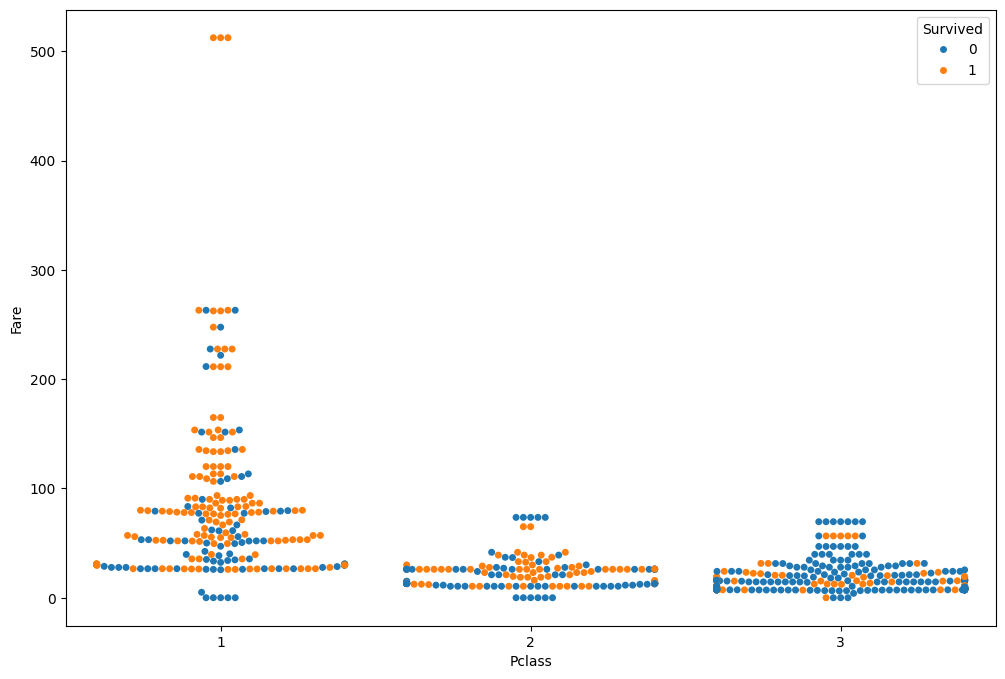

In [2]:
#влияние цены билета и класса
fig = plt.figure(figsize=(12,8))
sns.swarmplot(x="Pclass", y="Fare", data=train, hue="Survived")

#влияние класса и пола
train.groupby(['Pclass','Sex'])['Survived'].value_counts(normalize=True)



In [ ]:
train.select_dtypes(include=['number']).groupby("Survived").mean()




,Pclass,Age,SibSp,Parch,Fare
Survived,,,,,
0,2.531876,30.626179,0.553734,0.329690,22.117887
1,1.950292,28.343690,0.473684,0.464912,48.395408


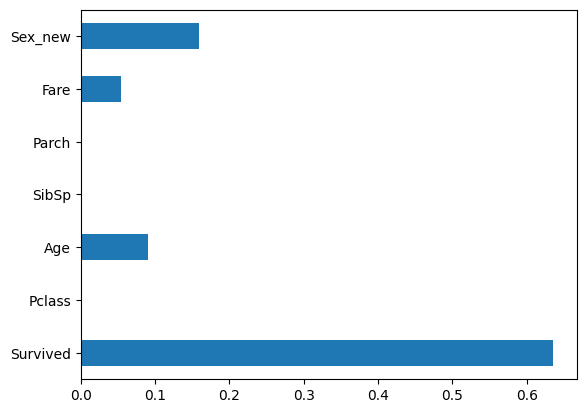

In [ ]:
train_copy = train.copy()
train_copy['Sex_new'] = train_copy['Sex'].map({'male': 0, 'female': 1})

train_clean = train_copy.dropna()
train_clean = train_clean.select_dtypes(include=['number'])
y_clean = y[train_clean.index] 

importances = mutual_info_classif(train_clean, y_clean)
feature_importances = pd.Series(importances, index=train_clean.columns)
feature_importances.plot(kind='barh')
plt.show()

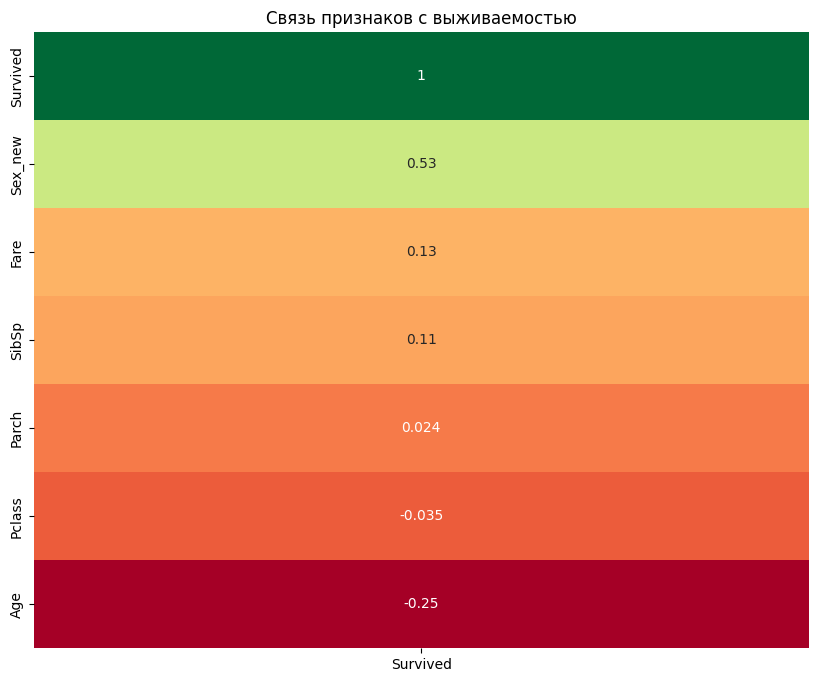

In [7]:

target_corr = train_clean.select_dtypes(include=['number']).corr()['Survived'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(target_corr.to_frame(), annot=True, cmap='RdYlGn', cbar=False)
plt.title('Связь признаков с выживаемостью')
plt.show()

TypeError: suptitle() missing 1 required positional argument: 't'

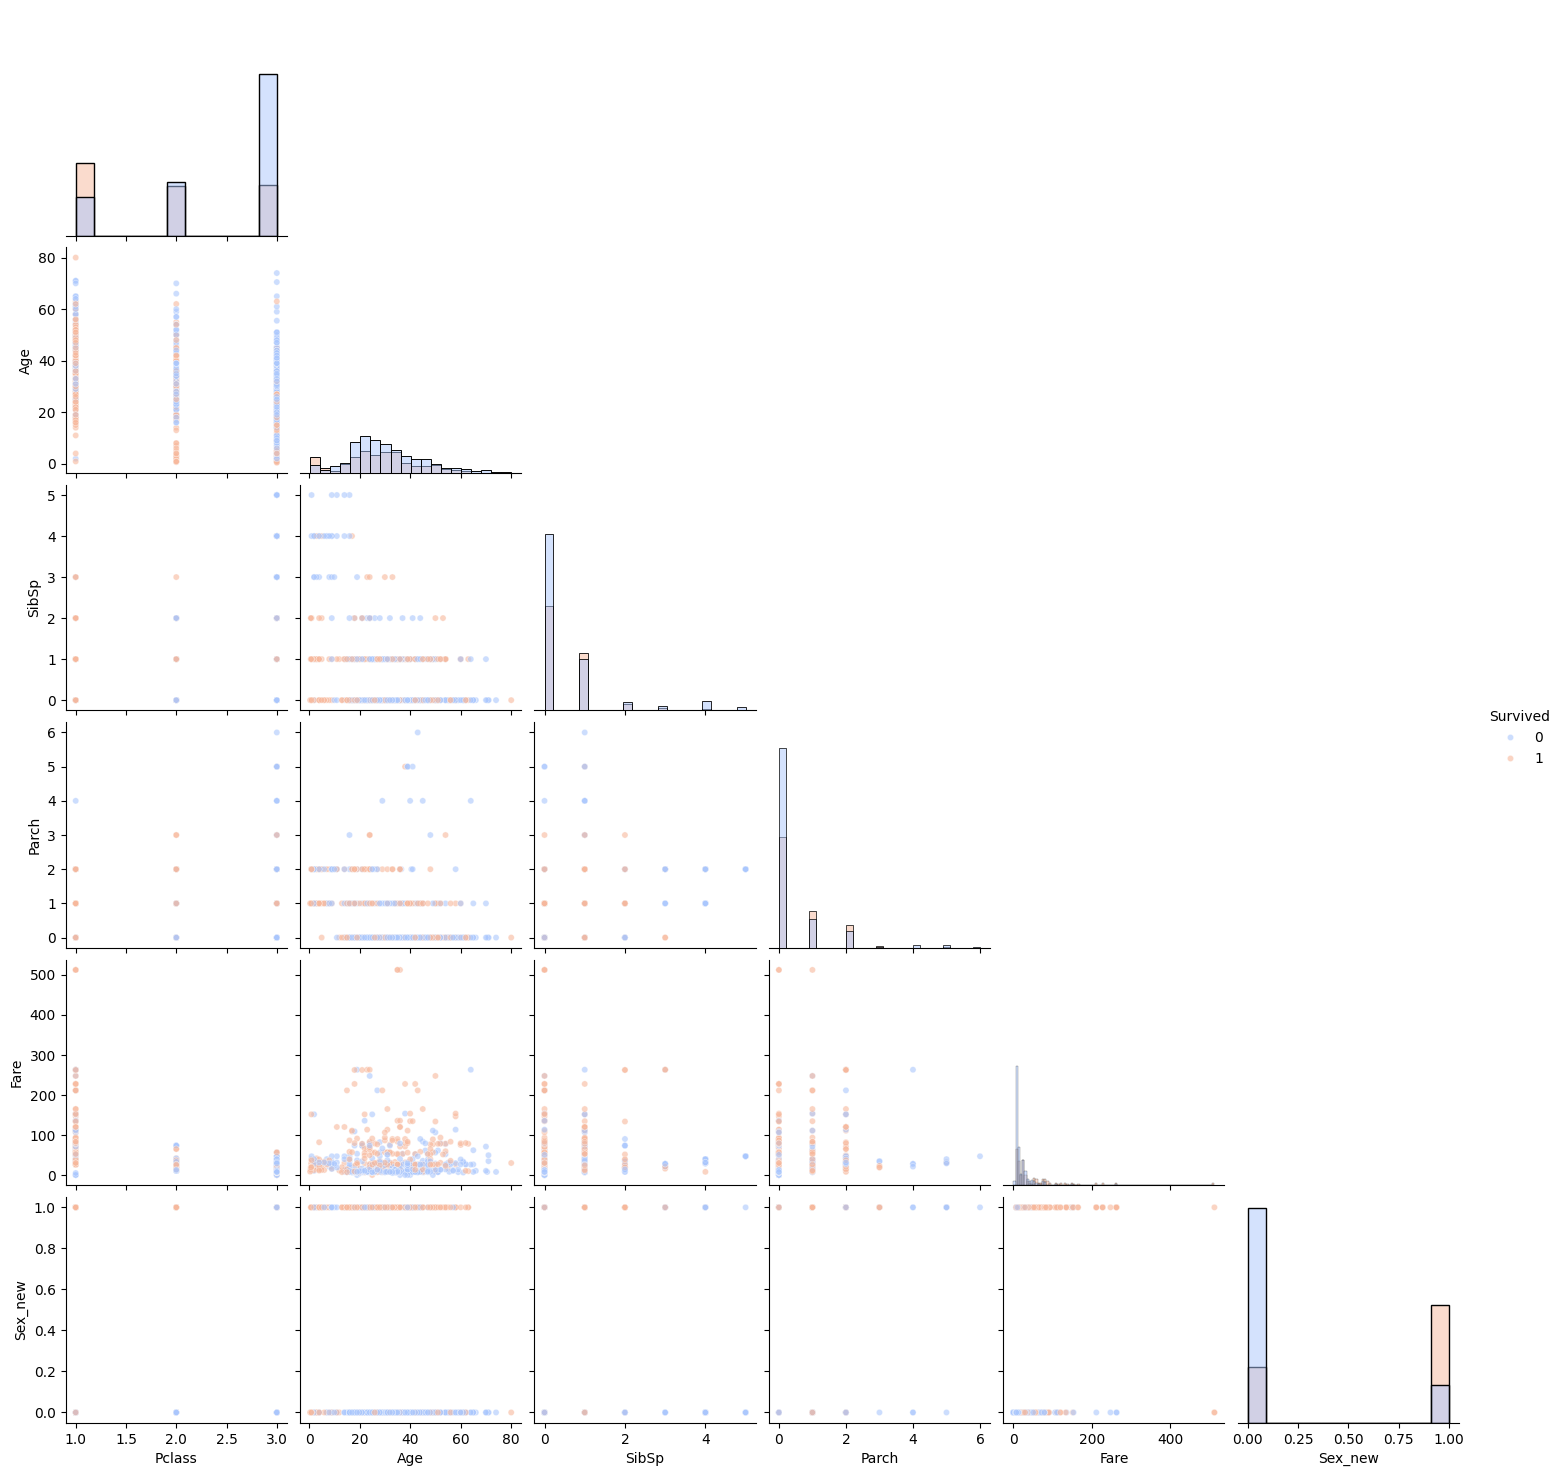

In [ ]:
numeric_cols = train_copy.select_dtypes(include='number').columns.tolist()
plot_data = train_copy[numeric_cols].dropna()
sns.pairplot(plot_data, 
             hue='Survived',  # раскраска по целевой переменной
             palette='coolwarm',
             plot_kws={'alpha': 0.6, 's': 20},
             diag_kind='hist', 
             corner=True)    

plt.suptitle('Анализ',y=2, fontsize=18)
plt.show()


# Хорошие индикаторы
У кого лучше класс, у тех больше была вероятность на выживание
Дети с возрастом < 10 чаще выживали
у кого дороже билет, те чаще выживали
Небольшие семьи чаще выживали
Женжины(в зависимости от класса) лучше выживали

SibSp — количество братьев/сестёр/супругов (у большинства 0-1)
Parch — количество родителей/детей (у большинства 0)

Можно объединить SibSp и Parch



In [ ]:
#processing
train['family'] = train['SibSp']+train['Parch']
train.drop("Cabin",axis=1)